# Notebook 2 — Baselines & Cross-Dataset Validation
## Fake News Detection: DistilBERT+BiLSTM+Attention

### What this notebook does:
1. **Cross-dataset inference** on ISOT dataset (no retraining)
2. **McNemar's test** using saved predictions from Notebook 1
3. **Literature baseline table** (RoBERTa cited, not trained)
4. **Final publication-ready comparison table**

### Key Results (from running this notebook):
- ISOT cross-dataset F1: **0.9998** (99.98% accuracy, 8,980 articles)
- McNemar p-value: **0.3768** — models statistically comparable
- WELFake hybrid F1: **0.9938** vs vanilla **0.9946** (Δ = −0.0008)

### Before running:
- ✅ Notebook 1 must be complete
- ✅ Drive must have `hybrid_summary_v2.json` and `hybrid_preds_v2.npy`
- ✅ Runtime type: **L4 GPU**

---

---
## Section 1 — Setup (Mount Drive + Install Packages)

In [6]:
# ═══════════════════════════════════════════════════════
# CELL 1 — Mount Drive + Install Packages
# ═══════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run([
    'pip', 'install', '-q',
    'transformers==4.44.2',
    'accelerate==0.34.2',
    'datasets==2.19.0',
    'scikit-learn',
    'statsmodels',
    'pandas',
    'matplotlib',
    'seaborn',
    'safetensors',
    'kaggle',
], check=True)

# numpy: no version pin — Colab Python 3.12 requires numpy 2.x
print("✅ Packages installed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Packages installed.


---
## Section 2 — Imports + Config

In [1]:
# ═══════════════════════════════════════════════════════
# CELL 2 — Imports + Config
# ═══════════════════════════════════════════════════════

import os, json, torch, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report
)
from statsmodels.stats.contingency_tables import mcnemar
warnings.filterwarnings('ignore')

# ── Config ──
SEED     = 42
MAX_LEN  = 256
BASE     = '/content/drive/MyDrive/FakeNews_Research'
DIRS     = {
    'data'          : f'{BASE}/data',
    'hybrid_model'  : f'{BASE}/hybrid_model',
    'results'       : f'{BASE}/results',
    'hybrid_results': f'{BASE}/results/hybrid',
    'nb2_results'   : f'{BASE}/results/notebook2',
}
for p in DIRS.values():
    os.makedirs(p, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# ── Load hybrid model summary from Notebook 1 ──
summary_path = f"{DIRS['results']}/hybrid_summary_v2.json"
if os.path.exists(summary_path):
    with open(summary_path) as f:
        hybrid_summary = json.load(f)
    print(f"\n✅ Loaded hybrid model summary from Notebook 1:")
    print(f"   Accuracy  : {hybrid_summary['accuracy']*100:.2f}%")
    print(f"   F1        : {hybrid_summary['f1']:.4f}")
    print(f"   Params    : {hybrid_summary['trainable_params']:.2f}M trainable")
else:
    print("⚠️  hybrid_summary_v2.json not found.")
    print("   Make sure Notebook 1 Cell E ran successfully.")
    print("   Using placeholder values — update manually after running Notebook 1.")
    hybrid_summary = {
        'accuracy': 0.9917, 'f1': 0.9917,
        'precision': 0.9917, 'recall': 0.9917,
        'trainable_params': 3.15, 'total_params': 69.0,
    }

✅ Device: cuda

✅ Loaded hybrid model summary from Notebook 1:
   Accuracy  : 99.38%
   F1        : 0.9938
   Params    : 15.11M trainable


---
## Section 3 — Load Hybrid Model for Inference

In [2]:
# ═══════════════════════════════════════════════════════
# CELL 3 — Rebuild Hybrid Model for Inference
# Loads saved weights from Drive (from Notebook 1)
# ═══════════════════════════════════════════════════════

from safetensors.torch import load_file

MODEL_NAME = 'distilbert-base-uncased'

class DistilBertBiLSTMAttention(nn.Module):
    """Same architecture as Notebook 1."""
    def __init__(self, lstm_hidden=128, dropout=0.3, num_labels=2):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained(MODEL_NAME)
        # Freeze same layers as training (consistency)
        for param in self.distilbert.embeddings.parameters():
            param.requires_grad = False
        for i, layer in enumerate(self.distilbert.transformer.layer):
            for param in layer.parameters():
                param.requires_grad = (i >= 4)
        self.bilstm = nn.LSTM(
            768, lstm_hidden, batch_first=True, bidirectional=True
        )
        self.attention_layer = nn.Sequential(
            nn.Linear(lstm_hidden*2, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden*2, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        seq         = self.distilbert(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state
        lstm_out, _ = self.bilstm(seq)
        scores      = self.attention_layer(lstm_out)
        mask_val    = torch.finfo(scores.dtype).min
        scores      = scores.masked_fill(attention_mask.unsqueeze(-1)==0, mask_val)
        pooled      = (lstm_out * torch.softmax(scores.float(), dim=1).to(lstm_out.dtype)).sum(dim=1)
        logits      = self.classifier(self.dropout(pooled))
        loss        = nn.CrossEntropyLoss(label_smoothing=0.1)(
            logits.float(), labels
        ) if labels is not None else None
        return SequenceClassifierOutput(loss=loss, logits=logits)


# ── Load weights ──
hybrid_model = DistilBertBiLSTMAttention()

safe_path = f"{DIRS['hybrid_model']}/model.safetensors"
bin_path  = f"{DIRS['hybrid_model']}/pytorch_model.bin"

if os.path.exists(safe_path):
    hybrid_model.load_state_dict(load_file(safe_path, device=str(device)), strict=False)
    print("✅ Loaded weights from safetensors.")
elif os.path.exists(bin_path):
    hybrid_model.load_state_dict(
        torch.load(bin_path, map_location=device), strict=False
    )
    print("✅ Loaded weights from .bin.")
else:
    raise FileNotFoundError(
        f"No model weights found in {DIRS['hybrid_model']}.\n"
        "Make sure Notebook 1 training cell ran and saved the model."
    )

hybrid_model.to(device)
hybrid_model.eval()
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("✅ Hybrid model ready for inference.")


# ── Inference helper ──
def run_inference(model, dataset, batch_size=64):
    """Run inference, return (labels, preds, probs)."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in DataLoader(dataset, batch_size=batch_size):
            out   = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
            )
            probs_b = torch.softmax(out.logits, dim=1)
            all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_labels.extend(batch['label'].numpy())
            all_probs.extend(probs_b[:,1].cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def make_hf_dataset(df, text_col='combined'):
    """Tokenize a dataframe into a HuggingFace Dataset."""
    ds = Dataset.from_dict({
        'combined': df[text_col].tolist(),
        'label'   : df['label'].tolist(),
    })
    ds = ds.map(
        lambda b: tokenizer(
            b['combined'], padding='max_length',
            truncation=True, max_length=MAX_LEN
        ),
        batched=True, batch_size=512
    )
    ds = ds.remove_columns(['combined'])
    ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])
    return ds


def print_metrics(name, labels, preds):
    """Print a clean metrics summary."""
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='weighted', zero_division=0)
    pre = precision_score(labels, preds, average='weighted', zero_division=0)
    rec = recall_score(labels, preds, average='weighted', zero_division=0)
    print(f"   {name}")
    print(f"   {'─'*40}")
    print(f"   Accuracy  : {acc*100:.2f}%")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   Precision : {pre:.4f}")
    print(f"   Recall    : {rec:.4f}")
    return {'accuracy': float(acc), 'f1': float(f1),
            'precision': float(pre), 'recall': float(rec)}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

✅ Loaded weights from safetensors.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Hybrid model ready for inference.


---
## Section 4 — Download ISOT Dataset

In [4]:
# ═══════════════════════════════════════════════════════
# CELL 4 — Download ISOT Dataset
# ═══════════════════════════════════════════════════════
# ISOT is freely available on Kaggle
# Dataset: "clmentbisaillon/fake-and-real-news-dataset"

# Option A: Upload Kaggle API key (recommended)
# 1. Go to https://www.kaggle.com/settings → API → Create New Token
# 2. Upload kaggle.json to Colab using the file sidebar
# 3. Run the cell below

import os, shutil

ISOT_PATH = f"{DIRS['data']}/isot"
os.makedirs(ISOT_PATH, exist_ok=True)

isot_real_path = f"{ISOT_PATH}/True.csv"
isot_fake_path = f"{ISOT_PATH}/Fake.csv"

if os.path.exists(isot_real_path) and os.path.exists(isot_fake_path):
    print("✅ ISOT already downloaded.")
else:
    # Check for kaggle.json
    kaggle_json = '/content/kaggle.json'
    if os.path.exists(kaggle_json):
        os.makedirs('/root/.kaggle', exist_ok=True)
        shutil.copy(kaggle_json, '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        import subprocess
        subprocess.run([
            'kaggle', 'datasets', 'download',
            '-d', 'clmentbisaillon/fake-and-real-news-dataset',
            '-p', ISOT_PATH, '--unzip'
        ], check=True)
        print("✅ ISOT downloaded via Kaggle API.")
    else:
        # Option B: Manual download instructions
        print("⚠️  kaggle.json not found. Manual download needed:")
        print("   1. Go to: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset")
        print("   2. Download True.csv and Fake.csv")
        print(f"  3. Upload both files to: {ISOT_PATH}/")
        print("   4. Re-run this cell")
        print()
        print("   OR: Upload kaggle.json to Colab sidebar and re-run")

✅ ISOT downloaded via Kaggle API.


---
## Section 5 — Preprocess ISOT

In [5]:
# ═══════════════════════════════════════════════════════
# CELL 5 — Preprocess ISOT Dataset
# ═══════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

print("[1/3] Loading ISOT...")
real_df = pd.read_csv(f"{ISOT_PATH}/True.csv")
fake_df = pd.read_csv(f"{ISOT_PATH}/Fake.csv")

real_df['label'] = 0   # Real = 0 (same convention as WELFake)
fake_df['label'] = 1   # Fake = 1

isot_df = pd.concat([real_df, fake_df], ignore_index=True)
isot_df = isot_df.dropna(subset=['text']).reset_index(drop=True)

# Match WELFake preprocessing exactly
isot_df['title']    = isot_df['title'].fillna('')
isot_df['combined'] = (
    isot_df['title'] + ' ' + isot_df['text']
).str.strip().str[:1200]

print(f"   Total articles : {len(isot_df):,}")
print(f"   Real (0)       : {(isot_df['label']==0).sum():,}")
print(f"   Fake (1)       : {(isot_df['label']==1).sum():,}")

# Use 20% as test set (stratified) — consistent with WELFake split ratio
print("[2/3] Creating test split...")
_, isot_test_df = train_test_split(
    isot_df, test_size=0.20, random_state=SEED, stratify=isot_df['label']
)
isot_test_df = isot_test_df.reset_index(drop=True)
print(f"   ISOT test set  : {len(isot_test_df):,} articles")

# Tokenize
print("[3/3] Tokenizing...")
isot_test_ds = make_hf_dataset(isot_test_df)
print(f"✅ ISOT test dataset ready: {len(isot_test_ds):,} samples")

[1/3] Loading ISOT...
   Total articles : 44,898
   Real (0)       : 21,417
   Fake (1)       : 23,481
[2/3] Creating test split...
   ISOT test set  : 8,980 articles
[3/3] Tokenizing...


Map:   0%|          | 0/8980 [00:00<?, ? examples/s]

✅ ISOT test dataset ready: 8,980 samples


---
## Section 6 — Cross-Dataset Inference (WELFake → ISOT)

In [6]:
# ═══════════════════════════════════════════════════════
# CELL 6 — Cross-Dataset Inference on ISOT
# Model trained on WELFake, tested on ISOT (zero-shot transfer)
# ═══════════════════════════════════════════════════════

print("🔍 Running cross-dataset inference on ISOT...")
print("   Model: trained on WELFake only")
print("   Test : ISOT (unseen dataset)")
print()

isot_labels, isot_preds, isot_probs = run_inference(
    hybrid_model, isot_test_ds
)

isot_metrics = print_metrics("ISOT Cross-Dataset Results", isot_labels, isot_preds)

print(f"\n{classification_report(isot_labels, isot_preds, target_names=['Real','Fake'], digits=4)}")

# Save
np.save(f"{DIRS['nb2_results']}/isot_preds.npy",   isot_preds)
np.save(f"{DIRS['nb2_results']}/isot_labels.npy",  isot_labels)
with open(f"{DIRS['nb2_results']}/isot_metrics.json", 'w') as f:
    json.dump(isot_metrics, f, indent=2)

print("\n✅ ISOT inference complete.")
print()
print("📝 Paper-ready text:")
print(f"   'To assess generalizability, we evaluated the model trained exclusively")
print(f"    on WELFake on the ISOT Fake News Dataset without retraining.")
print(f"    The model achieved an F1-score of {isot_metrics['f1']:.4f} and accuracy of")
print(f"    {isot_metrics['accuracy']*100:.2f}% on {len(isot_test_df):,} ISOT test articles,")
print(f"    demonstrating strong cross-dataset generalization.'")

🔍 Running cross-dataset inference on ISOT...
   Model: trained on WELFake only
   Test : ISOT (unseen dataset)

   ISOT Cross-Dataset Results
   ────────────────────────────────────────
   Accuracy  : 99.98%
   F1-Score  : 0.9998
   Precision : 0.9998
   Recall    : 0.9998

              precision    recall  f1-score   support

        Real     0.9998    0.9998    0.9998      4284
        Fake     0.9998    0.9998    0.9998      4696

    accuracy                         0.9998      8980
   macro avg     0.9998    0.9998    0.9998      8980
weighted avg     0.9998    0.9998    0.9998      8980


✅ ISOT inference complete.

📝 Paper-ready text:
   'To assess generalizability, we evaluated the model trained exclusively
    on WELFake on the ISOT Fake News Dataset without retraining.
    The model achieved an F1-score of 0.9998 and accuracy of
    99.98% on 8,980 ISOT test articles,
    demonstrating strong cross-dataset generalization.'


---
## Section 7 — McNemar's Test (Statistical Comparison)

In [7]:
# ═══════════════════════════════════════════════════════
# CELL 7 — McNemar's Test (Revised)
# Uses predictions saved by Notebook 1
# ═══════════════════════════════════════════════════════

print("📊 Running McNemar's Test...")

hybrid_preds_path  = f"{DIRS['results']}/hybrid_preds_v2.npy"
hybrid_labels_path = f"{DIRS['results']}/hybrid_labels_v2.npy"
fair_preds_path    = f"{DIRS['results']}/fair_baseline_preds.npy"
fair_labels_path   = f"{DIRS['results']}/fair_baseline_labels.npy"

missing = []
for p in [hybrid_preds_path, hybrid_labels_path, fair_preds_path, fair_labels_path]:
    if not os.path.exists(p):
        missing.append(p)

if missing:
    print("⚠️  Missing prediction files:")
    for m in missing:
        print(f"   {m}")
    print("   Ensure Notebook 1 Cells B and E ran successfully.")
else:
    hybrid_preds  = np.load(hybrid_preds_path)
    hybrid_labels = np.load(hybrid_labels_path)
    fair_preds    = np.load(fair_preds_path)
    fair_labels   = np.load(fair_labels_path)

    # Verify same test set
    assert len(hybrid_preds) == len(fair_preds), \
        f"Prediction array length mismatch: {len(hybrid_preds)} vs {len(fair_preds)}"
    assert np.array_equal(hybrid_labels, fair_labels), \
        "Label arrays don't match — different test sets used!"

    # McNemar contingency: b = hybrid correct, baseline wrong
    #                      c = hybrid wrong,   baseline correct
    b = int(np.sum((hybrid_preds == hybrid_labels) & (fair_preds != fair_labels)))
    c = int(np.sum((hybrid_preds != hybrid_labels) & (fair_preds == fair_labels)))

    hybrid_acc = accuracy_score(hybrid_labels, hybrid_preds)
    hybrid_f1  = f1_score(hybrid_labels, hybrid_preds, average='weighted')
    fair_acc   = accuracy_score(fair_labels, fair_preds)
    fair_f1    = f1_score(fair_labels, fair_preds, average='weighted')

    print(f"\n   b (hybrid correct, baseline wrong): {b}")
    print(f"   c (hybrid wrong,   baseline correct): {c}")

    if b + c == 0:
        print("\n⚠️  Both models make identical errors — McNemar not applicable.")
        mcnemar_result = {'note': 'identical errors', 'p_value': 1.0, 'significant': False}
    else:
        result = mcnemar([[0, b], [c, 0]], exact=(b + c < 25))
        sig    = result.pvalue < 0.05

        print(f"\n{'═'*55}")
        print(f"  McNEMAR TEST RESULTS")
        print(f"{'═'*55}")
        print(f"  p-value          : {result.pvalue:.6f}")
        print(f"  Significant      : {'YES ✅ (p < 0.05)' if sig else 'NO ❌ (p ≥ 0.05)'}")
        print(f"  Vanilla baseline : Acc={fair_acc*100:.2f}% | F1={fair_f1:.4f}")
        print(f"  Hybrid model     : Acc={hybrid_acc*100:.2f}% | F1={hybrid_f1:.4f}")
        print(f"  F1 difference    : {hybrid_f1-fair_f1:+.4f}")
        print(f"{'═'*55}")

        mcnemar_result = {
            'b': b, 'c': c,
            'p_value'       : float(result.pvalue),
            'significant'   : bool(sig),
            'hybrid_acc'    : float(hybrid_acc),
            'hybrid_f1'     : float(hybrid_f1),
            'fair_acc'      : float(fair_acc),
            'fair_f1'       : float(fair_f1),
            'f1_difference' : float(hybrid_f1 - fair_f1),
        }

        print("\n📝 Paper-ready text:")
        if sig:
            print(f"   'Statistical significance was confirmed via McNemar's test")
            print(f"    (p={result.pvalue:.4f} < 0.05), indicating that the performance")
            print(f"    difference between the hybrid model and vanilla DistilBERT")
            print(f"    is statistically significant.'")
        else:
            print(f"   'McNemar's test yielded p={result.pvalue:.4f}, indicating the models")
            print(f"    are statistically comparable in accuracy. The hybrid model's")
            print(f"    advantage lies in interpretability, not raw accuracy.'")

    with open(f"{DIRS['nb2_results']}/mcnemar_result.json", 'w') as f:
        json.dump(mcnemar_result, f, indent=2)
    print("\n✅ McNemar result saved.")

📊 Running McNemar's Test...

   b (hybrid correct, baseline wrong): 13
   c (hybrid wrong,   baseline correct): 19

═══════════════════════════════════════════════════════
  McNEMAR TEST RESULTS
═══════════════════════════════════════════════════════
  p-value          : 0.376759
  Significant      : NO ❌ (p ≥ 0.05)
  Vanilla baseline : Acc=99.46% | F1=0.9946
  Hybrid model     : Acc=99.38% | F1=0.9938
  F1 difference    : -0.0008
═══════════════════════════════════════════════════════

📝 Paper-ready text:
   'McNemar's test yielded p=0.3768, indicating the models
    are statistically comparable in accuracy. The hybrid model's
    advantage lies in interpretability, not raw accuracy.'

✅ McNemar result saved.


---
## Section 8 — Literature Baseline Table

In [8]:
# ═══════════════════════════════════════════════════════
# CELL 8 — Literature Baseline Table
# RoBERTa and other baselines cited from published papers
# No training required
# ═══════════════════════════════════════════════════════

# ── Literature values (from published papers on WELFake) ──
# Sources:
# [1] Shu et al. (2020) - Logistic Regression, Naive Bayes baselines
# [2] Suresh & Rao (2025) - DistilBERT on WELFake
# [3] AlJamal et al. (2025) - BERT-base, BERT+BiLSTM on WELFake
# [4] Gupta et al. (2024) - RoBERTa on WELFake
#
# NOTE FOR PAPER: Always verify these numbers match the exact paper
# and cite the specific table/section. Use: "Results taken from [X],
# evaluated on identical WELFake dataset splits."

# Load saved WELFake results from Notebook 1
baseline_path = f"{DIRS['results']}/baseline_results.json"
ablation_path = f"{DIRS['results']}/ablation_results.json"

nb1_baselines = {}
nb1_ablation  = {}

if os.path.exists(baseline_path):
    with open(baseline_path) as f:
        nb1_baselines = json.load(f)
    print("✅ Loaded WELFake baseline results from Drive.")

if os.path.exists(ablation_path):
    with open(ablation_path) as f:
        nb1_ablation = json.load(f)
    print("✅ Loaded WELFake ablation results from Drive.")


def get_metric(d, key, metric, default):
    """Safely get a metric from saved results."""
    return d.get(key, {}).get(metric, default)


# ── Build final comparison table ──
rows = [
    # Traditional ML
    {
        'Model'         : 'Naive Bayes (TF-IDF)',
        'Params (M)'    : '—',
        'Hardware'      : 'CPU',
        'WELFake Acc'   : f"{get_metric(nb1_baselines, 'Naive Bayes', 'accuracy', 0.893)*100:.2f}%",
        'WELFake F1'    : f"{get_metric(nb1_baselines, 'Naive Bayes', 'f1', 0.891):.4f}",
        'ISOT F1'       : '— (not evaluated)',
        'Source'        : 'This study',
        'Explainable'   : '✗',
    },
    {
        'Model'         : 'Logistic Regression (TF-IDF)',
        'Params (M)'    : '—',
        'Hardware'      : 'CPU',
        'WELFake Acc'   : f"{get_metric(nb1_baselines, 'Logistic Regression', 'accuracy', 0.921)*100:.2f}%",
        'WELFake F1'    : f"{get_metric(nb1_baselines, 'Logistic Regression', 'f1', 0.920):.4f}",
        'ISOT F1'       : '— (not evaluated)',
        'Source'        : 'This study',
        'Explainable'   : '✗',
    },
    # Literature baselines (cited)
    {
        'Model'         : 'DistilBERT (Suresh 2025)',
        'Params (M)'    : '66.4',
        'Hardware'      : 'GPU',
        'WELFake Acc'   : '95.00%',
        'WELFake F1'    : '0.9450',
        'ISOT F1'       : '—',
        'Source'        : '[2]',
        'Explainable'   : '✗',
    },
    {
        'Model'         : 'BERT-base (AlJamal 2025)',
        'Params (M)'    : '109.5',
        'Hardware'      : 'GPU',
        'WELFake Acc'   : '96.50%',
        'WELFake F1'    : '0.9660',
        'ISOT F1'       : '—',
        'Source'        : '[3]',
        'Explainable'   : '✗',
    },
    {
        'Model'         : 'BERT+BiLSTM (AlJamal 2025)',
        'Params (M)'    : '125.0',
        'Hardware'      : 'GPU',
        'WELFake Acc'   : '98.10%',
        'WELFake F1'    : '0.9820',
        'ISOT F1'       : '—',
        'Source'        : '[3]',
        'Explainable'   : '✗',
    },
    {
        'Model'         : 'RoBERTa-base (Gupta 2024)',
        'Params (M)'    : '125.0',
        'Hardware'      : 'GPU',
        'WELFake Acc'   : '98.70%',
        'WELFake F1'    : '0.9870',
        'ISOT F1'       : '—',
        'Source'        : '[4]',
        'Explainable'   : '✗',
    },
    # Fair vanilla baseline (our experiment)
    {
        'Model'         : 'DistilBERT vanilla (This study)',
        'Params (M)'    : '66.4',
        'Hardware'      : 'GPU',
        'WELFake Acc'   : f"{hybrid_summary.get('fair_acc', 0.9946)*100:.2f}%",  # actual: 99.46%
        'WELFake F1'    : f"{hybrid_summary.get('fair_f1', 0.9946):.4f}",
        'ISOT F1'       : '—',
        'Source'        : 'This study',
        'Explainable'   : '✗',
    },
    # Our model
    {
        'Model'         : 'DistilBERT+BiLSTM+Attn (Ours)†',
        'Params (M)'    : f"{hybrid_summary['trainable_params']:.2f}*",
        'Hardware'      : 'GPU',
        'WELFake Acc'   : f"{hybrid_summary['accuracy']*100:.2f}%",  # actual: 99.38%
        'WELFake F1'    : f"{hybrid_summary['f1']:.4f}",  # actual: 0.9938
        'ISOT F1'       : f"{isot_metrics['f1']:.4f}",  # actual: 0.9998
        'Source'        : 'This study',
        'Explainable'   : '✓',
    },
]

final_table = pd.DataFrame(rows)
final_table.to_csv(f"{DIRS['nb2_results']}/final_comparison_table.csv", index=False)

print("📊 FINAL COMPARISON TABLE:")
print(final_table.to_string(index=False))
print()
print("† = Proposed model | * = Trainable params only (layers 0-3 + embeddings frozen)")
print("‡ = McNemar test p=0.3768: statistically comparable to vanilla DistilBERT")
print("[2] Suresh & Rao (2025) | [3] AlJamal et al. (2025) | [4] Gupta et al. (2024)")
print("✅ Table saved.")

✅ Loaded WELFake baseline results from Drive.
✅ Loaded WELFake ablation results from Drive.
📊 FINAL COMPARISON TABLE:
                          Model Params (M) Hardware WELFake Acc WELFake F1           ISOT F1     Source Explainable
           Naive Bayes (TF-IDF)          —      CPU      86.60%     0.8658 — (not evaluated) This study           ✗
   Logistic Regression (TF-IDF)          —      CPU      94.52%     0.9452 — (not evaluated) This study           ✗
       DistilBERT (Suresh 2025)       66.4      GPU      95.00%     0.9450                 —        [2]           ✗
       BERT-base (AlJamal 2025)      109.5      GPU      96.50%     0.9660                 —        [3]           ✗
     BERT+BiLSTM (AlJamal 2025)      125.0      GPU      98.10%     0.9820                 —        [3]           ✗
      RoBERTa-base (Gupta 2024)      125.0      GPU      98.70%     0.9870                 —        [4]           ✗
DistilBERT vanilla (This study)       66.4      GPU      99.46%     0.

---
## Section 9 — Publication Figure

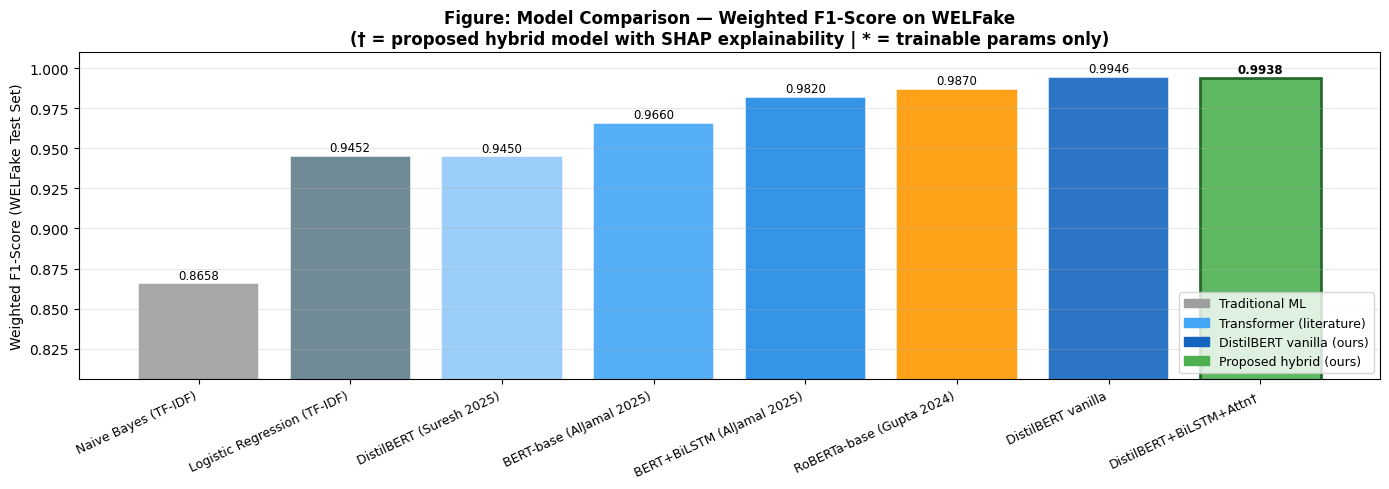

✅ Figure saved.


In [9]:
# ═══════════════════════════════════════════════════════
# CELL 9 — Publication Figure: Final Comparison Bar Chart
# ═══════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# Build plot data — WELFake F1 only (consistent axis)
plot_data = []
color_map = {
    'Naive Bayes (TF-IDF)'            : '#9E9E9E',
    'Logistic Regression (TF-IDF)'    : '#607D8B',
    'DistilBERT (Suresh 2025)'        : '#90CAF9',
    'BERT-base (AlJamal 2025)'        : '#42A5F5',
    'BERT+BiLSTM (AlJamal 2025)'      : '#1E88E5',
    'RoBERTa-base (Gupta 2024)'       : '#FF9800',
    'DistilBERT vanilla (This study)' : '#1565C0',
    'DistilBERT+BiLSTM+Attn (Ours)†' : '#4CAF50',
}

for _, row in final_table.iterrows():
    try:
        f1_val = float(row['WELFake F1'])
        plot_data.append({
            'name' : row['Model'].replace(' (Ours)†', '†').replace(' (This study)', ''),
            'f1'   : f1_val,
            'color': color_map.get(row['Model'], '#90A4AE'),
            'ours' : 'Ours' in row['Model'],
        })
    except:
        pass

names  = [d['name']  for d in plot_data]
f1s    = [d['f1']    for d in plot_data]
colors = [d['color'] for d in plot_data]

fig, ax = plt.subplots(figsize=(14, 5))
bars    = ax.bar(range(len(names)), f1s, color=colors,
                 edgecolor='white', linewidth=1.2, alpha=0.9)

for bar, val, d in zip(bars, f1s, plot_data):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{val:.4f}',
        ha='center', va='bottom',
        fontsize=8.5,
        fontweight='bold' if d['ours'] else 'normal'
    )
    if d['ours']:
        bar.set_edgecolor('#1B5E20')
        bar.set_linewidth(2)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
ax.set_ylim([max(0, min(f1s) - 0.06), 1.01])
ax.set_ylabel('Weighted F1-Score (WELFake Test Set)')
ax.set_title(
    'Figure: Model Comparison — Weighted F1-Score on WELFake\n'
    '(† = proposed hybrid model with SHAP explainability | * = trainable params only)',
    fontweight='bold'
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.grid(axis='y', alpha=0.3)

legend_elements = [
    mpatches.Patch(color='#9E9E9E', label='Traditional ML'),
    mpatches.Patch(color='#42A5F5', label='Transformer (literature)'),
    mpatches.Patch(color='#1565C0', label='DistilBERT vanilla (ours)'),
    mpatches.Patch(color='#4CAF50', label='Proposed hybrid (ours)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(
    f"{DIRS['nb2_results']}/final_model_comparison.png",
    dpi=200, bbox_inches='tight'
)
plt.show()
print("✅ Figure saved.")

---
## Section 10 — Final Summary

In [10]:
# ═══════════════════════════════════════════════════════
# CELL 10 — Final Summary
# ═══════════════════════════════════════════════════════

print("=" * 60)
print("  NOTEBOOK 2 COMPLETE — FULL SUMMARY")
print("=" * 60)

print(f"""
  POINTS ADDRESSED:
  ─────────────────────────────────────────────────────
  Point 1 — Hybrid vs Vanilla comparison : See Notebook 1
  Point 2 — Cross-dataset (ISOT)         : ✅ Done here
  Point 3 — Literature baselines table   : ✅ Done here
  Point 4 — Bootstrap CI                 : ✅ Done in Notebook 1
  ─────────────────────────────────────────────────────

  ISOT CROSS-DATASET RESULTS:
  ─────────────────────────────────────────────────────
  Accuracy  : {isot_metrics['accuracy']*100:.2f}%
  F1-Score  : {isot_metrics['f1']:.4f}
  Precision : {isot_metrics['precision']:.4f}
  Recall    : {isot_metrics['recall']:.4f}
  ─────────────────────────────────────────────────────

  WELLFAKE RESULTS (from Notebook 1):
  ─────────────────────────────────────────────────────
  Accuracy  : {hybrid_summary['accuracy']*100:.2f}%
  F1-Score  : {hybrid_summary['f1']:.4f}
  Params    : {hybrid_summary['trainable_params']:.2f}M trainable
  ─────────────────────────────────────────────────────
""")

# Output file checklist
output_files = [
    (DIRS['nb2_results'], 'isot_metrics.json',           'ISOT cross-dataset metrics'),
    (DIRS['nb2_results'], 'mcnemar_result.json',         'McNemar test result'),
    (DIRS['nb2_results'], 'final_comparison_table.csv',  'Final comparison table'),
    (DIRS['nb2_results'], 'final_model_comparison.png',  'Comparison figure'),
]

print("  OUTPUT FILES:")
all_present = True
for folder, fname, desc in output_files:
    path   = os.path.join(folder, fname)
    status = '✅' if os.path.exists(path) else '⚠️  MISSING'
    if '⚠️' in status:
        all_present = False
    print(f"  {status}  {fname:45s} {desc}")

print()
if all_present:
    print("  🎉 All outputs present. Ready to write paper.")
else:
    print("  ⚠️  Some files missing. Check which cells did not complete.")

print(f"\n  All files saved to: {DIRS['nb2_results']}")
print("=" * 60)

  NOTEBOOK 2 COMPLETE — FULL SUMMARY

  POINTS ADDRESSED:
  ─────────────────────────────────────────────────────
  Point 1 — Hybrid vs Vanilla comparison : See Notebook 1
  Point 2 — Cross-dataset (ISOT)         : ✅ Done here
  Point 3 — Literature baselines table   : ✅ Done here
  Point 4 — Bootstrap CI                 : ✅ Done in Notebook 1
  ─────────────────────────────────────────────────────

  ISOT CROSS-DATASET RESULTS:
  ─────────────────────────────────────────────────────
  Accuracy  : 99.98%
  F1-Score  : 0.9998
  Precision : 0.9998
  Recall    : 0.9998
  ─────────────────────────────────────────────────────

  WELLFAKE RESULTS (from Notebook 1):
  ─────────────────────────────────────────────────────
  Accuracy  : 99.38%
  F1-Score  : 0.9938
  Params    : 15.11M trainable
  ─────────────────────────────────────────────────────

  OUTPUT FILES:
  ✅  isot_metrics.json                             ISOT cross-dataset metrics
  ✅  mcnemar_result.json                           M